In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import json
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family":       "serif",
    "font.size":         11,
    "axes.titlesize":    12,
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

SEED         = 42
PARQUET_PATH = r"C:\Users\super\Desktop\Data Thesis\final_df_clustered.parquet"
BASELINE_PT  = r"C:\Users\super\Desktop\Data Thesis\BaselinesGrid\transformer_best.pt"
FAIR_PT      = r"C:\Users\super\Desktop\Data Thesis\BaselinesGrid\transformer_fair.pt"
BEST_PARAMS  = r"C:\Users\super\Desktop\Data Thesis\BaselinesGrid\transformer_best_params.json"
MAX_SEQ_LEN  = 80
BATCH_SIZE   = 32
N_BOOTSTRAP  = 1000
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(SEED)
torch.manual_seed(SEED)

print("Loading data...")
final_df = pd.read_parquet(PARQUET_PATH)

gaze_cols = [c for c in final_df.columns if "gaze" in c]
pose_cols = [c for c in final_df.columns if "pose" in c]
au_r_cols = [c for c in final_df.columns if c.startswith("AU") and c.endswith("_r")]
au_c_cols = [c for c in final_df.columns if c.startswith("AU") and c.endswith("_c")]
FEATURE_COLS = au_r_cols + au_c_cols + gaze_cols + pose_cols
N_FEATURES   = len(FEATURE_COLS)

print(f"  Features: {N_FEATURES}  |  Participants: {final_df['participant_id'].nunique()}")

Loading data...
  Features: 49  |  Participants: 102


In [2]:
participant_label = (
    final_df.groupby("participant_id")["engagement"]
    .agg(lambda x: int(x.mean() >= 0.5))
)
engaged_participants    = participant_label[participant_label == 1].index.values.copy()
disengaged_participants = participant_label[participant_label == 0].index.values.copy()

rng = np.random.default_rng(SEED)
rng.shuffle(engaged_participants)
rng.shuffle(disengaged_participants)

def stratified_split(arr, train_frac=0.70, val_frac=0.15):
    n       = len(arr)
    n_train = int(n * train_frac)
    n_val   = int(n * val_frac)
    return arr[:n_train], arr[n_train:n_train + n_val], arr[n_train + n_val:]

train_eng, val_eng, test_eng = stratified_split(engaged_participants)
train_dis, val_dis, test_dis = stratified_split(disengaged_participants)

train_participants = np.concatenate([train_eng, train_dis])
test_participants   = np.concatenate([test_eng,  test_dis])

train_mask = final_df["participant_id"].isin(train_participants)

clip_meta = (
    final_df.groupby("clip_id")
    .agg(engagement=("engagement", "first"),
         participant_id=("participant_id", "first"),
         behavioral_cluster=("behavioral_cluster", "first"))
    .reset_index()
)

test_clips = clip_meta[clip_meta["participant_id"].isin(test_participants)].reset_index(drop=True)

scaler = StandardScaler()
scaler.fit(final_df.loc[train_mask, FEATURE_COLS])
final_df[FEATURE_COLS] = scaler.transform(final_df[FEATURE_COLS])

print(f"Test clips reconstructed: {len(test_clips)}")
print(test_clips["behavioral_cluster"].value_counts())

Test clips reconstructed: 1777
behavioral_cluster
1    1261
0     516
Name: count, dtype: int64


In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=MAX_SEQ_LEN, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe           = torch.zeros(max_len, d_model)
        position     = torch.arange(0, max_len).unsqueeze(1).float()
        div_term     = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=8, num_layers=1,
                 dim_feedforward=64, dropout=0.3, n_classes=2,
                 max_len=MAX_SEQ_LEN):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_enc    = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x):
        x   = self.pos_enc(self.input_proj(x))
        x   = self.encoder(x)
        rep = self.dropout(x.mean(dim=1))
        return self.classifier(rep)


class EngagementDataset(Dataset):
    def __init__(self, clips_df, full_df, max_len=MAX_SEQ_LEN):
        self.max_len  = max_len
        self.clip_ids = clips_df["clip_id"].tolist()
        self.labels   = clips_df["engagement"].tolist()
        self.clusters = clips_df["behavioral_cluster"].tolist()
        relevant      = full_df[full_df["clip_id"].isin(self.clip_ids)]
        self.clip_dict = {
            cid: grp.sort_values("timestep")[FEATURE_COLS].values.astype(np.float32)
            for cid, grp in relevant.groupby("clip_id")
        }

    def __len__(self):
        return len(self.clip_ids)

    def __getitem__(self, idx):
        seq = self.clip_dict.get(
            self.clip_ids[idx],
            np.zeros((1, N_FEATURES), dtype=np.float32)
        )
        T = seq.shape[0]
        if T >= self.max_len:
            seq = seq[:self.max_len]
        else:
            seq = np.vstack([seq, np.zeros((self.max_len - T, N_FEATURES),
                                           dtype=np.float32)])
        return (torch.tensor(seq),
                torch.tensor(self.labels[idx],   dtype=torch.long),
                torch.tensor(self.clusters[idx], dtype=torch.long))


def load_model(checkpoint_path):
    with open(BEST_PARAMS) as f:
        params = json.load(f)
    model = TransformerClassifier(
        input_dim       = N_FEATURES,
        d_model         = int(params["d_model"]),
        nhead           = int(params["nhead"]),
        num_layers      = int(params["num_layers"]),
        dim_feedforward = int(params["dim_feedforward"]),
        dropout         = params["dropout"]
    ).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()
    return model


print("Loading both models and running inference once on the full test set...")
test_dataset = EngagementDataset(test_clips, final_df)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

baseline_model = load_model(BASELINE_PT)
fair_model     = load_model(FAIR_PT)

def run_inference(model, loader):
    preds, labels, clusters = [], [], []
    with torch.no_grad():
        for X_batch, y_batch, c_batch in loader:
            preds.extend(model(X_batch.to(DEVICE)).argmax(dim=1).cpu().numpy())
            labels.extend(y_batch.numpy())
            clusters.extend(c_batch.numpy())
    return np.array(preds), np.array(labels), np.array(clusters)

preds_baseline, labels_baseline, clusters_baseline = run_inference(baseline_model, test_loader)
preds_fair,     labels_fair,     clusters_fair     = run_inference(fair_model,     test_loader)

assert np.array_equal(labels_baseline, labels_fair)
assert np.array_equal(clusters_baseline, clusters_fair)
labels   = labels_baseline
clusters = clusters_baseline
print(f"Inference complete. Test set size: {len(labels)}")

Loading both models and running inference once on the full test set...
Inference complete. Test set size: 1777


In [4]:
def compute_disparity_metrics(preds, labels, clusters):
    cluster_stats = {}
    for c in [0, 1]:
        mask = clusters == c
        yt, yp = labels[mask], preds[mask]
        tp = ((yt == 1) & (yp == 1)).sum()
        fn = ((yt == 1) & (yp == 0)).sum()
        fp = ((yt == 0) & (yp == 1)).sum()
        tn = ((yt == 0) & (yp == 0)).sum()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        err = (fp + fn) / mask.sum() if mask.sum() > 0 else np.nan
        cluster_stats[c] = {"tpr": tpr, "fpr": fpr, "error_rate": err}

    eod              = abs(cluster_stats[0]["tpr"] - cluster_stats[1]["tpr"])
    fpr_gap          = abs(cluster_stats[0]["fpr"] - cluster_stats[1]["fpr"])
    worst_group_err  = max(cluster_stats[0]["error_rate"], cluster_stats[1]["error_rate"])
    return eod, fpr_gap, worst_group_err


eod_baseline_point, fprgap_baseline_point, wge_baseline_point = compute_disparity_metrics(
    preds_baseline, labels, clusters
)
eod_fair_point, fprgap_fair_point, wge_fair_point = compute_disparity_metrics(
    preds_fair, labels, clusters
)

print("Point estimates:")
print(f"  Baseline — EOD: {eod_baseline_point:.4f}  FPR gap: {fprgap_baseline_point:.4f}  WGE: {wge_baseline_point:.4f}")
print(f"  Fair     — EOD: {eod_fair_point:.4f}  FPR gap: {fprgap_fair_point:.4f}  WGE: {wge_fair_point:.4f}")
print(f"  Difference (baseline - fair) — EOD: {eod_baseline_point - eod_fair_point:.4f}, "
      f"FPR gap: {fprgap_baseline_point - fprgap_fair_point:.4f}, "
      f"WGE: {wge_baseline_point - wge_fair_point:.4f}")

Point estimates:
  Baseline — EOD: 0.1508  FPR gap: 0.4581  WGE: 0.3023
  Fair     — EOD: 0.1265  FPR gap: 0.4166  WGE: 0.2442
  Difference (baseline - fair) — EOD: 0.0243, FPR gap: 0.0415, WGE: 0.0581


In [5]:
np.random.seed(SEED)
n_test = len(labels)

eod_diffs, fprgap_diffs, wge_diffs = [], [], []

for b in range(N_BOOTSTRAP):
    boot_idx = np.random.choice(n_test, size=n_test, replace=True)

    boot_labels   = labels[boot_idx]
    boot_clusters = clusters[boot_idx]
    boot_preds_baseline = preds_baseline[boot_idx]
    boot_preds_fair     = preds_fair[boot_idx]

    eod_b, fprgap_b, wge_b = compute_disparity_metrics(boot_preds_baseline, boot_labels, boot_clusters)
    eod_f, fprgap_f, wge_f = compute_disparity_metrics(boot_preds_fair,     boot_labels, boot_clusters)

    eod_diffs.append(eod_b - eod_f)
    fprgap_diffs.append(fprgap_b - fprgap_f)
    wge_diffs.append(wge_b - wge_f)

eod_diffs    = np.array(eod_diffs)
fprgap_diffs = np.array(fprgap_diffs)
wge_diffs    = np.array(wge_diffs)

def summarize_diff(diffs, name, point_estimate):
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    excludes_zero = (ci_lo > 0) or (ci_hi < 0)
    print(f"\n{name}")
    print(f"  Point estimate of difference (baseline - fair): {point_estimate:.4f}")
    print(f"  95% bootstrap CI of difference: [{ci_lo:.4f}, {ci_hi:.4f}]")
    print(f"  Excludes zero: {excludes_zero}  -->  "
          f"{'STATISTICALLY MEANINGFUL improvement' if excludes_zero else 'NOT statistically distinguishable from no change'}")
    return ci_lo, ci_hi, excludes_zero

print("=" * 70)
print("PAIRED BOOTSTRAP TEST: Is baseline-vs-fair difference distinguishable from zero?")
print("=" * 70)

eod_ci    = summarize_diff(eod_diffs,    "EOD (baseline - fair)",
                            eod_baseline_point - eod_fair_point)
fprgap_ci = summarize_diff(fprgap_diffs, "FPR gap (baseline - fair)",
                            fprgap_baseline_point - fprgap_fair_point)
wge_ci    = summarize_diff(wge_diffs,    "Worst-group error (baseline - fair)",
                            wge_baseline_point - wge_fair_point)

PAIRED BOOTSTRAP TEST: Is baseline-vs-fair difference distinguishable from zero?

EOD (baseline - fair)
  Point estimate of difference (baseline - fair): 0.0243
  95% bootstrap CI of difference: [-0.0232, 0.0731]
  Excludes zero: False  -->  NOT statistically distinguishable from no change

FPR gap (baseline - fair)
  Point estimate of difference (baseline - fair): 0.0415
  95% bootstrap CI of difference: [-0.0626, 0.1420]
  Excludes zero: False  -->  NOT statistically distinguishable from no change

Worst-group error (baseline - fair)
  Point estimate of difference (baseline - fair): 0.0581
  95% bootstrap CI of difference: [0.0257, 0.0988]
  Excludes zero: True  -->  STATISTICALLY MEANINGFUL improvement


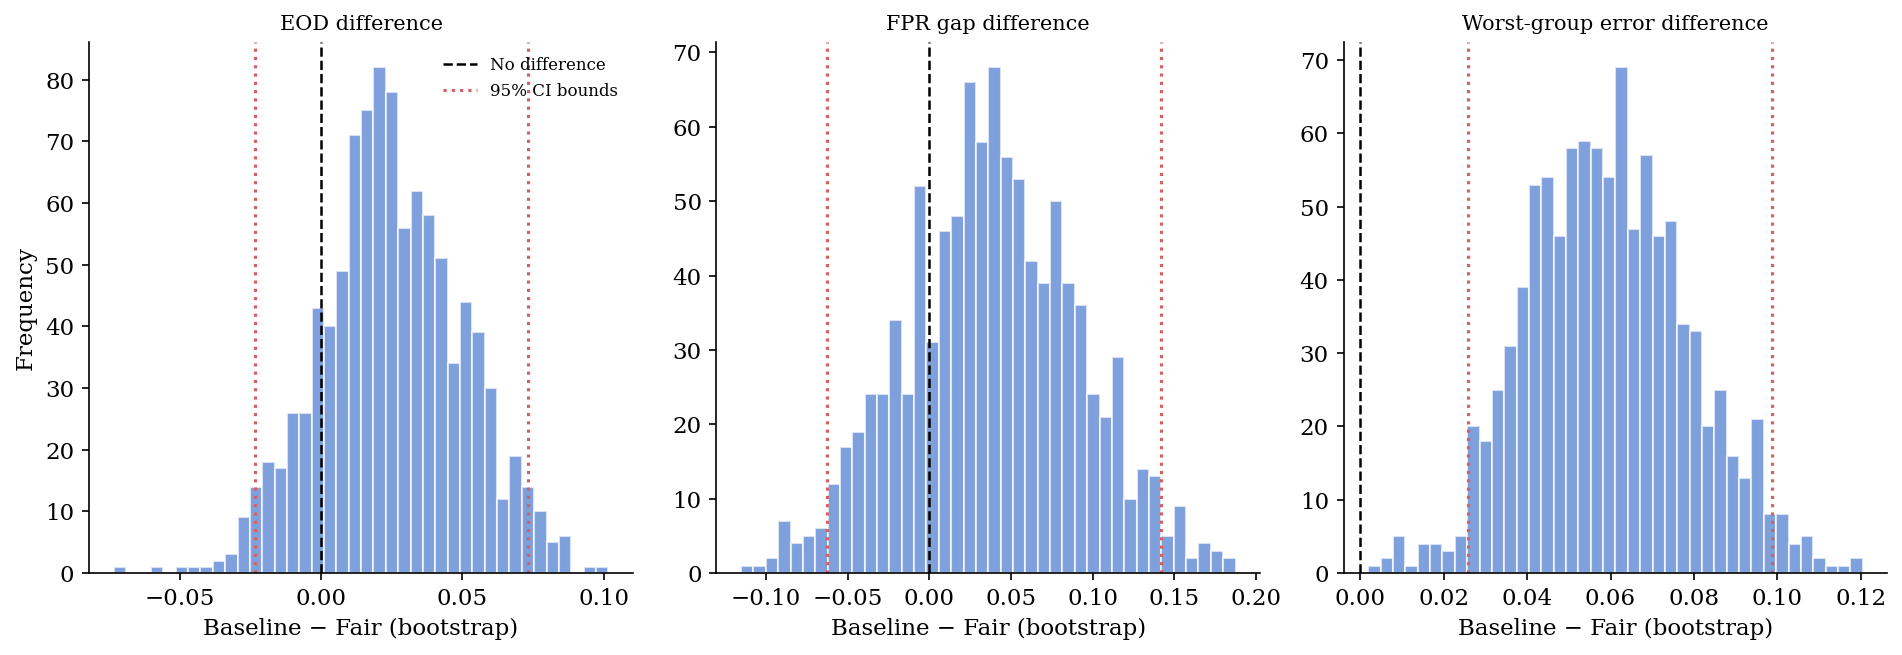

Saved: fig_paired_bootstrap_diff.pdf/.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

diff_data  = [eod_diffs, fprgap_diffs, wge_diffs]
diff_names = ["EOD difference", "FPR gap difference", "Worst-group error difference"]
diff_cis   = [eod_ci, fprgap_ci, wge_ci]

for ax, diffs, name, (ci_lo, ci_hi, excludes_zero) in zip(axes, diff_data, diff_names, diff_cis):
    ax.hist(diffs, bins=40, color="#4878CF", alpha=0.7, edgecolor="white")
    ax.axvline(0, color="black", linestyle="--", linewidth=1.2, label="No difference")
    ax.axvline(ci_lo, color="#D65F5F", linestyle=":", linewidth=1.5)
    ax.axvline(ci_hi, color="#D65F5F", linestyle=":", linewidth=1.5, label="95% CI bounds")
    ax.set_title(f"{name}", fontsize=10)
    ax.set_xlabel("Baseline − Fair (bootstrap)")

axes[0].legend(frameon=False, fontsize=8)
axes[0].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("fig_paired_bootstrap_diff.pdf", bbox_inches="tight")
plt.savefig("fig_paired_bootstrap_diff.png", bbox_inches="tight")
plt.show()
print("Saved: fig_paired_bootstrap_diff.pdf/.png")